# Conditional Autoencoder for Asset Pricing - Part 1: The Data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
idx = pd.IndexSlice
sns.set_style("whitegrid")

In [3]:
results_path = Path("results", "asset_pricing")
if not results_path.exists():
    results_path.mkdir(parents=True)

## Load Data

### Prices

In [6]:
prices = pd.read_hdf(results_path / "data.h5", "stocks/prices/adjusted")

In [7]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 6078122 entries, ('AAL', Timestamp('2005-09-27 00:00:00')) to ('ZYXI', Timestamp('2019-12-30 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   close   6078122 non-null  float64
 1   high    6078122 non-null  float64
 2   low     6078122 non-null  float64
 3   open    6078122 non-null  float64
 4   volume  6078122 non-null  float64
dtypes: float64(5)
memory usage: 255.5+ MB


### Metadata

In [8]:
metadata = pd.read_hdf(results_path / "data.h5", "stocks/info").rename(
    columns=str.lower
)

In [9]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4064 entries, AACB to ZYXI
Columns: 205 entries, address1 to exchangetransferdate
dtypes: bool(5), float64(140), int64(8), object(52)
memory usage: 6.3+ MB


### Select tickers with metadata

In [10]:
sectors = (metadata.sector.value_counts() > 50).index

In [13]:
tickers_with_errors = ["FTAI", "AIRT", "CYBR"]

In [14]:
tickers_with_metadata = metadata[
    metadata.sector.isin(sectors)
    & metadata.marketcap.notnull()
    & metadata.sharesoutstanding.notnull()
    & (metadata.sharesoutstanding > 0)
].index.drop(tickers_with_errors)

In [15]:
metadata = metadata.loc[
    tickers_with_metadata, ["sector", "sharesoutstanding", "marketcap"]
]
metadata.index.name = "ticker"

In [18]:
available_tickers = prices.index.get_level_values('ticker').unique().intersection(tickers_with_metadata)

In [20]:
prices = prices.loc[idx[available_tickers, :], :]

In [21]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 6025952 entries, ('AAL', Timestamp('2005-09-27 00:00:00')) to ('ZYXI', Timestamp('2019-12-30 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   close   6025952 non-null  float64
 1   high    6025952 non-null  float64
 2   low     6025952 non-null  float64
 3   open    6025952 non-null  float64
 4   volume  6025952 non-null  float64
dtypes: float64(5)
memory usage: 253.3+ MB


In [22]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3364 entries, AACB to ZYXI
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sector             3364 non-null   object 
 1   sharesoutstanding  3364 non-null   float64
 2   marketcap          3364 non-null   float64
dtypes: float64(2), object(1)
memory usage: 105.1+ KB


In [23]:
close = prices.close.unstack("ticker").sort_index()
close.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7558 entries, 1990-01-02 to 2019-12-30
Columns: 1662 entries, AAL to ZYXI
dtypes: float64(1662)
memory usage: 95.9 MB


In [24]:
volume = prices.volume.unstack("ticker").sort_index()
volume.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7558 entries, 1990-01-02 to 2019-12-30
Columns: 1662 entries, AAL to ZYXI
dtypes: float64(1662)
memory usage: 95.9 MB


### Create weekly returns

In [25]:
returns = (
    prices.close.unstack("ticker")
    .resample("W-FRI")
    .last()
    .sort_index()
    .pct_change()
    .iloc[1:]
)
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1565 entries, 1990-01-12 to 2020-01-03
Freq: W-FRI
Columns: 1662 entries, AAL to ZYXI
dtypes: float64(1662)
memory usage: 19.9 MB


In [26]:
dates = returns.index

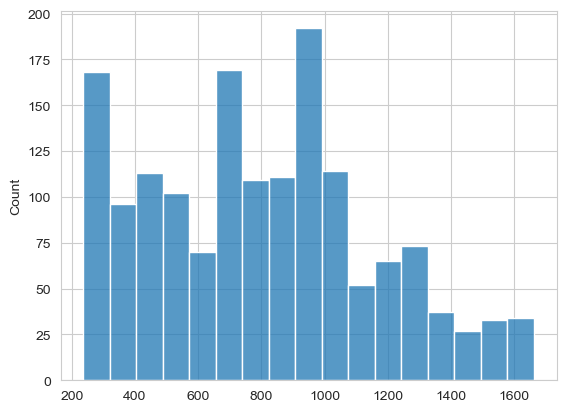

In [30]:
sns.histplot(returns.count(1));

In [31]:
with pd.HDFStore(results_path / "autoencoder.h5") as store:
    store.put("close", close)
    store.put("volume", volume)
    store.put("returns", returns)
    store.put("metadata", metadata)

## Factor Engineering

In [32]:
MONTH = 21

### Price Trend

#### Short-Term Reversal

1-month cumulative return

In [33]:
dates[:5]

DatetimeIndex(['1990-01-12', '1990-01-19', '1990-01-26', '1990-02-02',
               '1990-02-09'],
              dtype='datetime64[ns]', name='date', freq='W-FRI')

In [34]:
mom1m = (
    close.pct_change(periods=MONTH).resample("W-FRI").last().stack().to_frame("mom1m")
)
mom1m.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1243426 entries, (Timestamp('1990-02-02 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   mom1m   1243426 non-null  float64
dtypes: float64(1)
memory usage: 14.3+ MB


In [35]:
mom1m.squeeze().to_hdf(results_path / "autoencoder.h5", "factor/mom1m")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\473872736.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  mom1m.squeeze().to_hdf(results_path / "autoencoder.h5", "factor/mom1m")


#### Stock Momentum

11-month cumulative returns ending 1-month before month end

In [36]:
mom12m = (
    close.pct_change(periods=11 * MONTH)
    .shift(MONTH)
    .resample("W-FRI")
    .last()
    .stack()
    .to_frame("mom12m")
)

In [37]:
mom12m.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1167218 entries, (Timestamp('1991-01-04 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   mom12m  1167218 non-null  float64
dtypes: float64(1)
memory usage: 13.5+ MB


In [ ]:
mom12m.to_hdf(results_path / "autoencoder.h5", "factor/mom12m")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\3337157978.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  mom12m.to_hdf(results_path / "autoencoder.h5", "factor/mom12m")


#### Momentum Change

Cumulative return from months t-6 to t-1 minus months t-12 to t-7.

In [39]:
chmom = (
    close.pct_change(periods=6 * MONTH)
    .sub(close.pct_change(periods=6 * MONTH).shift(6 * MONTH))
    .resample("W-FRI")
    .last()
    .stack()
    .to_frame("chmom")
)

In [40]:
chmom.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1167218 entries, (Timestamp('1991-01-04 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   chmom   1167218 non-null  float64
dtypes: float64(1)
memory usage: 13.5+ MB


In [41]:
chmom.to_hdf(results_path / "autoencoder.h5", "factor/chmom")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\3939445990.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  chmom.to_hdf(results_path / "autoencoder.h5", "factor/chmom")


#### Industry Momentum

Equal-weighted avg. industry 12-month returns

In [42]:
indmom = (
    close.pct_change(12 * MONTH)
    .resample("W-FRI")
    .last()
    .stack()
    .to_frame("close")
    .join(metadata[["sector"]])
    .groupby(["date", "sector"])
    .close.mean()
    .to_frame("indmom")
    .reset_index()
)

In [43]:
indmom.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16654 entries, 0 to 16653
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    16654 non-null  datetime64[ns]
 1   sector  16654 non-null  object        
 2   indmom  16654 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 390.5+ KB


In [44]:
indmom = (
    returns.stack()
    .to_frame("ret")
    .join(metadata[["sector"]])
    .reset_index()
    .merge(indmom)
    .set_index(["date", "ticker"])
    .loc[:, ["indmom"]]
)

In [45]:
indmom.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1236699 entries, (Timestamp('1991-01-04 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   indmom  1236699 non-null  float64
dtypes: float64(1)
memory usage: 14.3+ MB


In [46]:
indmom.to_hdf(results_path / "autoencoder.h5", "factor/indmom")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\1396709406.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  indmom.to_hdf(results_path / "autoencoder.h5", "factor/indmom")


#### Recent Max Return

Max daily returns from calendar month t-1

In [47]:
maxret = (
    close.pct_change(periods=MONTH)
    .rolling(21)
    .max()
    .resample("W-FRI")
    .last()
    .stack()
    .to_frame("maxret")
)

In [48]:
maxret.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1236566 entries, (Timestamp('1990-03-02 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   maxret  1236566 non-null  float64
dtypes: float64(1)
memory usage: 14.3+ MB


In [49]:
maxret.to_hdf(results_path / "autoencoder.h5", "factor/maxret")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\4082988236.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  maxret.to_hdf(results_path / "autoencoder.h5", "factor/maxret")


#### Long-Term Reversal

Cumulative returns months t-36 to t-13.

In [50]:
mom36m = (
    close.pct_change(periods=24 * MONTH)
    .shift(12 * MONTH)
    .resample("W-FRI")
    .last()
    .stack()
    .to_frame("mom36m")
)

In [51]:
mom36m.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1021243 entries, (Timestamp('1993-01-01 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   mom36m  1021243 non-null  float64
dtypes: float64(1)
memory usage: 11.8+ MB


In [52]:
mom36m.to_hdf(results_path / "autoencoder.h5", "factor/mom36m")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\1626145189.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  mom36m.to_hdf(results_path / "autoencoder.h5", "factor/mom36m")


### Liquidity Metrics

#### Turnover

Avg. monthly trading volume for most recent three months scaled by number of shares; we are using the most recent no of shares from yahoo finance

In [53]:
turn = (
    volume.rolling(3 * MONTH)
    .mean()
    .resample("W-FRI")
    .last()
    .div(metadata.sharesoutstanding)
    .stack("ticker")
    .to_frame("turn")
)

In [54]:
turn.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1229540 entries, (Timestamp('1990-03-30 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   turn    1229540 non-null  float64
dtypes: float64(1)
memory usage: 14.3+ MB


In [55]:
turn.to_hdf(results_path / "autoencoder.h5", "factor/turn")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\3557150433.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  turn.to_hdf(results_path / "autoencoder.h5", "factor/turn")


#### Turnover Volatility

Monthly std dev of daily share turnover

In [56]:
turn_std = (
    prices.volume.unstack("ticker")
    .div(metadata.sharesoutstanding)
    .rolling(MONTH)
    .std()
    .resample("W-FRI")
    .last()
    .stack("ticker")
    .to_frame("turn_std")
)

In [57]:
turn_std.to_hdf(results_path / "autoencoder.h5", "factor/turn_std")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\4124722419.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  turn_std.to_hdf(results_path / "autoencoder.h5", "factor/turn_std")


#### Log Market Equity

Natural log of market cap at end of month t-1

In [58]:
last_price = close.ffill()
factor = close.div(last_price.iloc[-1])
mvel = (
    np.log1p(factor.mul(metadata.marketcap).resample("W-FRI").last())
    .stack()
    .to_frame("mvel")
)

In [59]:
mvel.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1250697 entries, (Timestamp('1990-01-05 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   mvel    1250697 non-null  float64
dtypes: float64(1)
memory usage: 14.5+ MB


In [60]:
mvel.to_hdf(results_path / "autoencoder.h5", "factor/mvel")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\1106190256.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  mvel.to_hdf(results_path / "autoencoder.h5", "factor/mvel")


#### Dollar Volume

Natural log of trading volume time price per share from month t-2

In [61]:
dv = close.mul(volume)

In [62]:
dolvol = (
    np.log1p(dv.rolling(21).mean().shift(21).resample("W-FRI").last())
    .stack()
    .to_frame("dolvol")
)

In [63]:
dolvol.to_hdf(results_path / "autoencoder.h5", "factor/dolvol")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\1098833668.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  dolvol.to_hdf(results_path / "autoencoder.h5", "factor/dolvol")


#### Amihud Illiquidity

Average of daily (absolute return / dollar volume)

In [64]:
ill = (
    close.pct_change()
    .abs()
    .div(dv)
    .rolling(21)
    .mean()
    .resample("W-FRI")
    .last()
    .stack()
    .to_frame("ill")
)

In [65]:
ill.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1023162 entries, (Timestamp('1990-02-02 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   ill     1023162 non-null  float64
dtypes: float64(1)
memory usage: 11.8+ MB


In [66]:
ill.to_hdf(results_path / "autoencoder.h5", "factor/ill")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\3256421777.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  ill.to_hdf(results_path / "autoencoder.h5", "factor/ill")


### Risk Measures

#### Return Volatility

Standard dev of daily returns from month t-1.

In [67]:
retvol = (
    close.pct_change()
    .rolling(21)
    .std()
    .resample("W-FRI")
    .last()
    .stack()
    .to_frame("retvol")
)

In [68]:
retvol.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1243426 entries, (Timestamp('1990-02-02 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   retvol  1243426 non-null  float64
dtypes: float64(1)
memory usage: 14.3+ MB


In [69]:
retvol.to_hdf(results_path / "autoencoder.h5", "factor/retvol")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\4120427365.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  retvol.to_hdf(results_path / "autoencoder.h5", "factor/retvol")


#### Market Beta

Estimated market beta from weekly returns and equal weighted market returns for 3 years ending month t-1 with at least 52 weeks of returns.

In [70]:
index = close.resample("W-FRI").last().pct_change().mean(1).to_frame("x")

In [71]:
def get_market_beta(y, x=index):
    df = x.join(y.to_frame("y")).dropna()
    model = RollingOLS(endog=df.y, exog=sm.add_constant(df[["x"]]), window=3 * 52)

    return model.fit(params_only=True).params["x"]

In [72]:
beta = (
    returns.dropna(thresh=3 * 52, axis=1)
    .apply(get_market_beta)
    .stack()
    .to_frame("beta")
)

In [73]:
beta.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1021992 entries, (Timestamp('1993-01-01 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   beta    1021992 non-null  float64
dtypes: float64(1)
memory usage: 11.8+ MB


In [74]:
beta.to_hdf(results_path / "autoencoder.h5", "factor/beta")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\1420733239.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  beta.to_hdf(results_path / "autoencoder.h5", "factor/beta")


#### Beta Squared

Market beta squared

In [75]:
betasq = beta.beta.pow(2).to_frame("betasq")

In [76]:
betasq.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1021992 entries, (Timestamp('1993-01-01 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   betasq  1021992 non-null  float64
dtypes: float64(1)
memory usage: 11.8+ MB


In [77]:
betasq.to_hdf(results_path / "autoencoder.h5", "factor/betasq")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\170962573.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  betasq.to_hdf(results_path / "autoencoder.h5", "factor/betasq")


#### Idiosyncratic return volatility

Standard dev of a regression of residuals of weekly returns on the returns of an equal weighted market index returns for the prior three years.

This takes a while!

In [78]:
def get_ols_residuals(y, x=index):
    df = x.join(y.to_frame("y")).dropna()
    model = sm.OLS(endog=df.y, exog=sm.add_constant(df[["x"]]))
    result = model.fit()
    return result.resid.std()

In [79]:
idiovol = returns.apply(lambda x: x.rolling(3 * 52).apply(get_ols_residuals))

In [80]:
idiovol = idiovol.stack().to_frame("idiovol")

In [81]:
idiovol.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1021992 entries, (Timestamp('1993-01-01 00:00:00'), 'AAME') to (Timestamp('2020-01-03 00:00:00'), 'ZYXI')
Data columns (total 1 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   idiovol  1021992 non-null  float64
dtypes: float64(1)
memory usage: 11.8+ MB


In [82]:
idiovol.to_hdf(results_path / "autoencoder.h5", "factor/idiovol")

C:\Users\paxto\AppData\Local\Temp\ipykernel_51528\1410501443.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  idiovol.to_hdf(results_path / "autoencoder.h5", "factor/idiovol")
